# Деревья решений. Снедков Валентин, ЕТ-128
1. Выполните классификацию набора данных из задания о Байесовской классификации с помощью построения дерева решений, варьируя следующие параметры: критерий выбора атрибута разбиения (information gain, index gini) и соотношение мощностей обучающей и тестовой выборок (от 60%:40% до 90%:10% с шагом 5%). Выполните визуализацию построенных деревьев решений.
2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм.
3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
* формулировка задания;
* гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
* рисунки с результатами визуализации;
* пояснения, раскрывающие смысл полученных результатов.

In [ ]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Загрузка датасета Iris (Цветы ириса)
iris = datasets.load_iris()
X = iris.data
# X = X + np.random.normal(0, 0.5, X.shape)
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Размерность данных:", X.shape)
print("Названия признаков:", feature_names)
print("Названия классов:", target_names)

Размерность данных: (150, 4)
Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Названия классов: ['setosa' 'versicolor' 'virginica']


In [ ]:
# Варьируем соотношения мощностей обучающей (от 60 до 90 % с шагом 5) и тестовой выборок
train_ratios = list(range(60, 95, 5))

# Критерии для сравнения
criteria = ['gini', 'entropy']

# Словари для хранения метрик по каждому критерию
metrics = {
    'gini': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'entropy': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
}

# Словари для хранения обученных моделей
models = {'gini': [], 'entropy': []}

In [ ]:
# Обучение моделей и сбор метрик
for criterion in criteria:
    for tr in train_ratios:
        ratio = tr / 100
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=ratio, random_state=24, stratify=y
        )

        # Обучаем дерево решений
        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=None,
            random_state=24
        )
        model.fit(X_train, y_train)

        # Сохраняем модель для визуализации
        models[criterion].append(model)

        # Предсказание и оценка метрик
        y_pred = model.predict(X_test)

        metrics[criterion]['accuracy'].append(accuracy_score(y_test, y_pred))
        metrics[criterion]['precision'].append(precision_score(y_test, y_pred, average='macro'))
        metrics[criterion]['recall'].append(recall_score(y_test, y_pred, average='macro'))
        metrics[criterion]['f1'].append(f1_score(y_test, y_pred, average='macro'))

In [ ]:
# Выводим метрики в виде таблицы
for criterion in criteria:
    print(f"\nКритерий: {criterion.upper()}")
    print("-"*60)
    print(f"{'Размер':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
    print("-"*60)
    for i, tr in enumerate(train_ratios):
        print(f"{tr}%:{100-tr}%    {metrics[criterion]['accuracy'][i]:<12.4f} "
              f"{metrics[criterion]['precision'][i]:<12.4f} "
              f"{metrics[criterion]['recall'][i]:<12.4f} "
              f"{metrics[criterion]['f1'][i]:<12.4f}")


Критерий: GINI
------------------------------------------------------------
Размер     Accuracy     Precision    Recall       F1-score    
------------------------------------------------------------
60%:40%    0.9333       0.9444       0.9333       0.9327      
65%:35%    0.9434       0.9524       0.9444       0.9441      
70%:30%    0.9333       0.9444       0.9333       0.9327      
75%:25%    0.9211       0.9375       0.9231       0.9220      
80%:20%    0.9667       0.9697       0.9667       0.9666      
85%:15%    0.9565       0.9630       0.9583       0.9582      
90%:10%    0.9333       0.9444       0.9333       0.9327      

Критерий: ENTROPY
------------------------------------------------------------
Размер     Accuracy     Precision    Recall       F1-score    
------------------------------------------------------------
60%:40%    0.9333       0.9444       0.9333       0.9327      
65%:35%    0.9434       0.9524       0.9444       0.9441      
70%:30%    0.9333       0.94

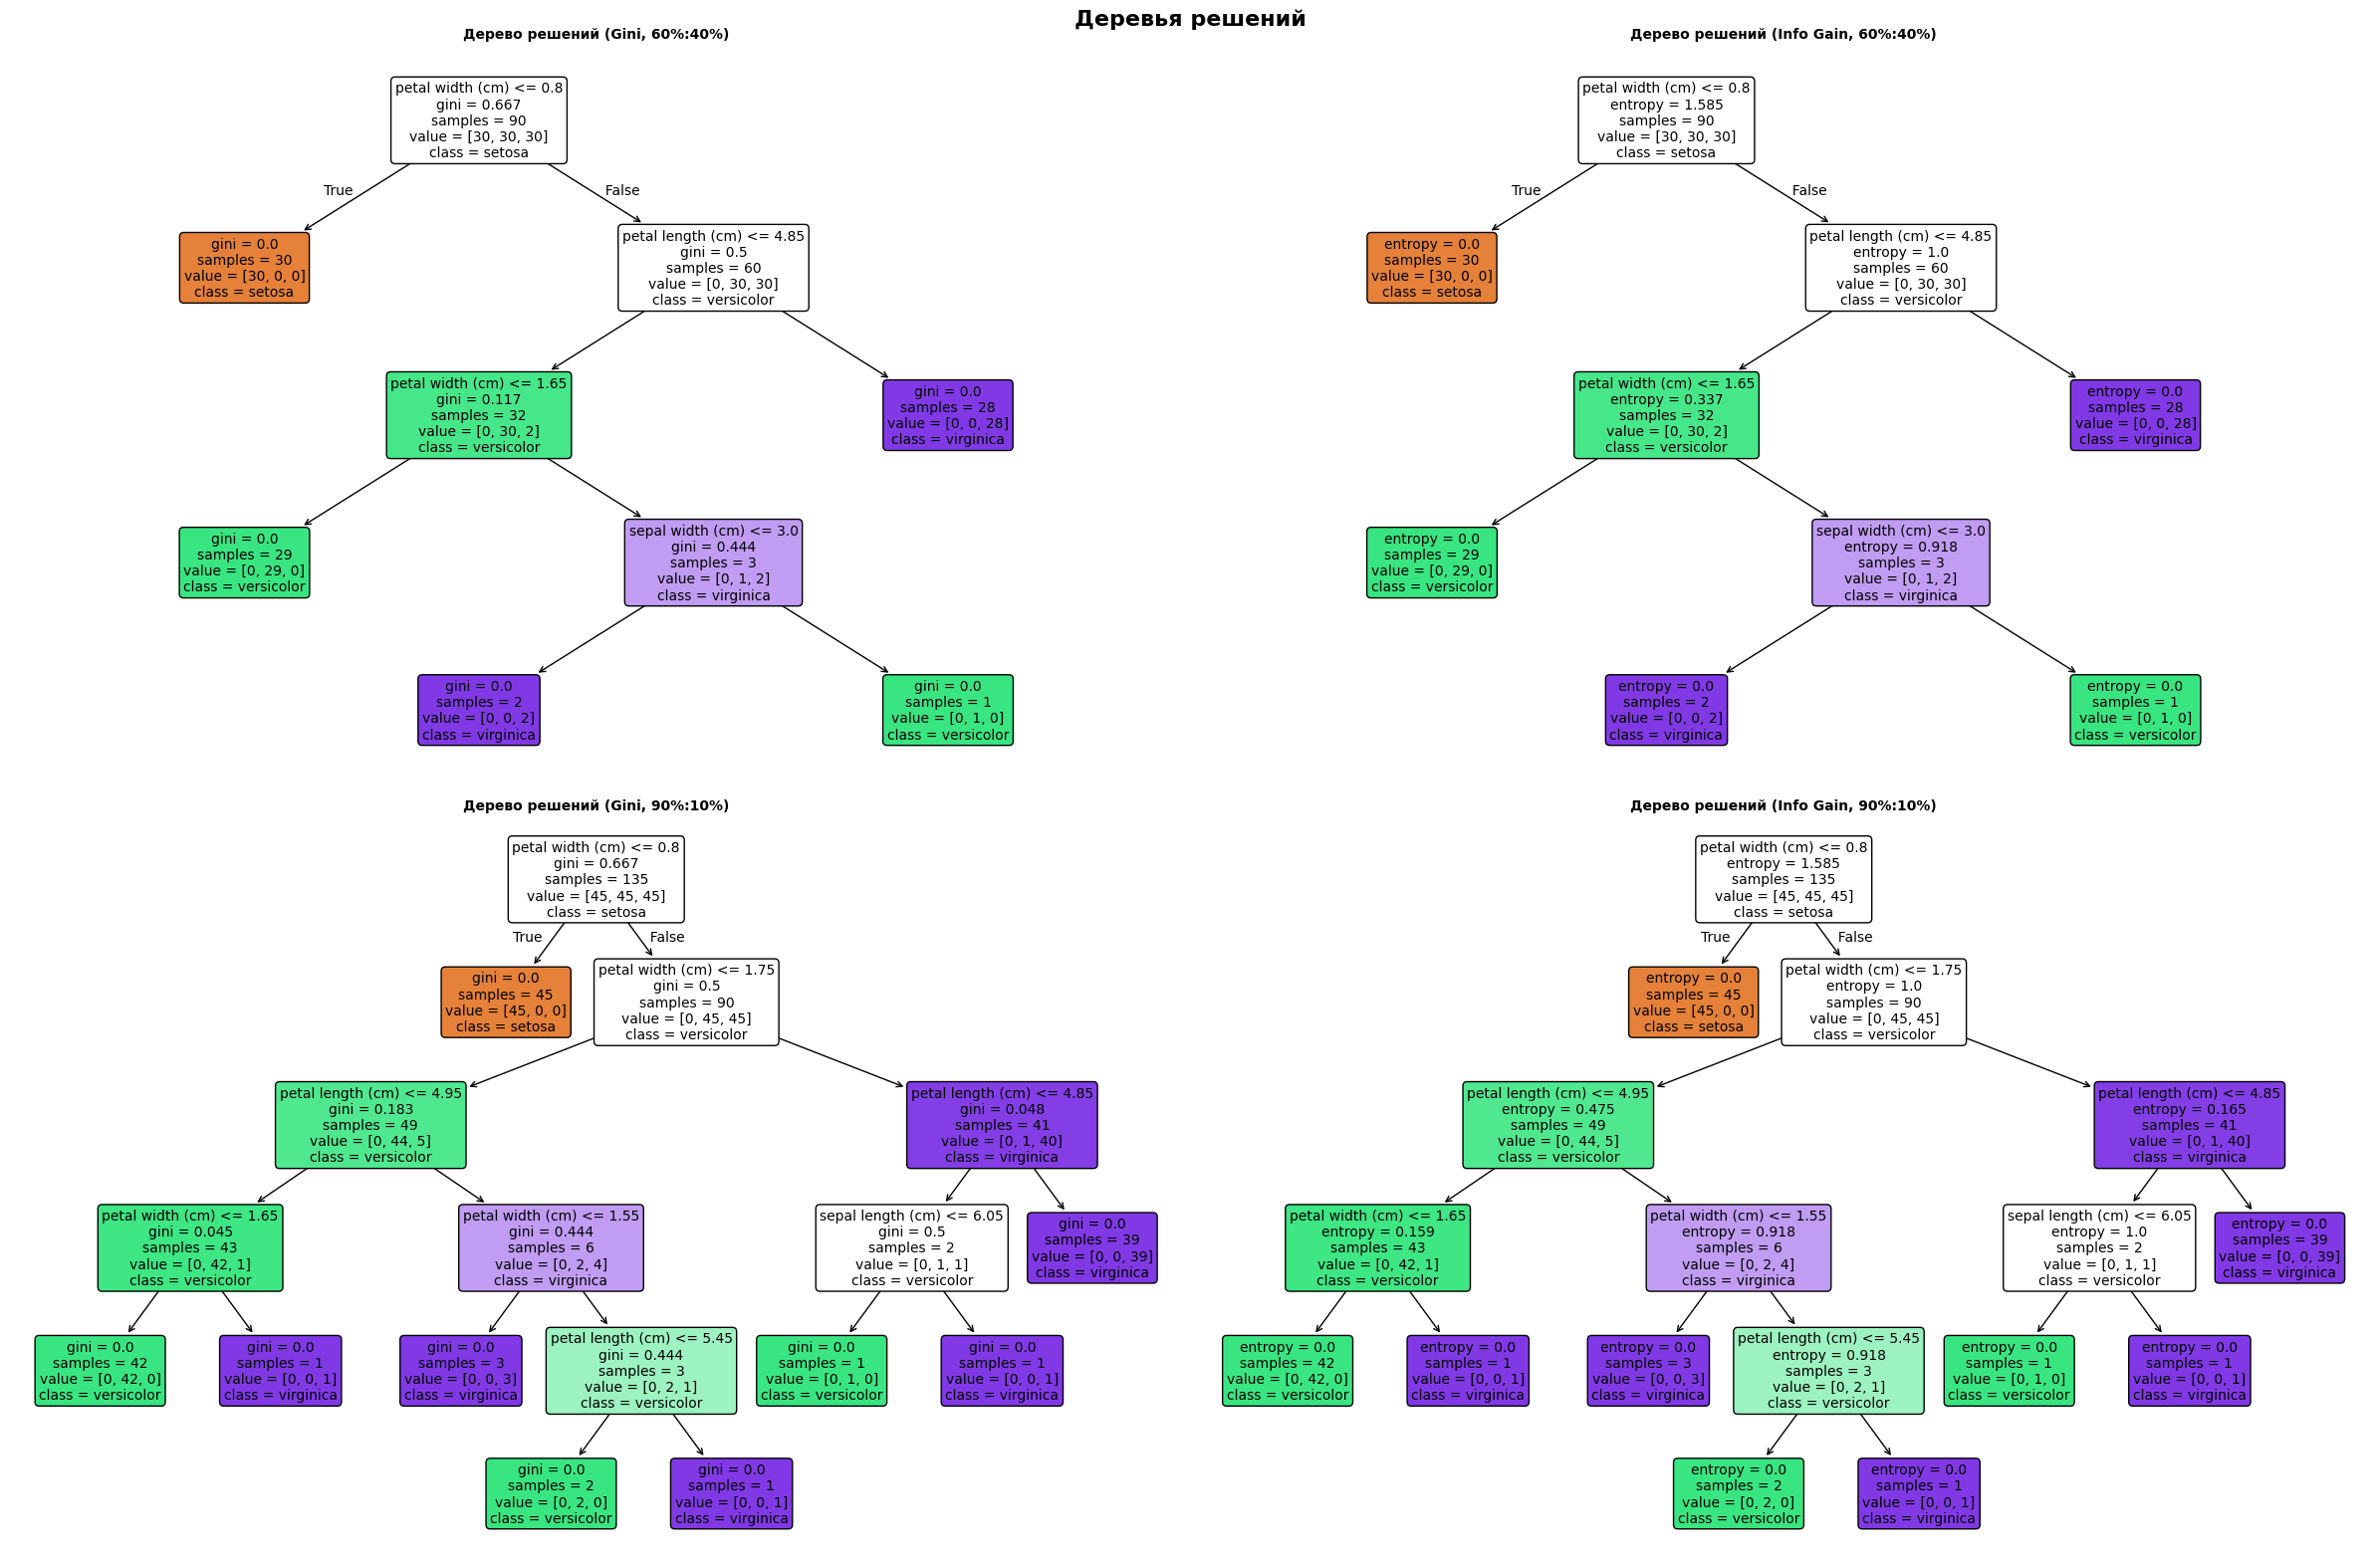

In [ ]:
# Визуализация деревьев решений для крайних значений (60% и 90%) для обоих критериев
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# Индексы для 60% и 90%
idx_60 = 0
idx_90 = -1

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
titles = [
    f'Дерево решений (Gini, 60%:{100-train_ratios[idx_60]}%)',
    f'Дерево решений (Info Gain, 60%:{100-train_ratios[idx_60]}%)',
    f'Дерево решений (Gini, 90%:{100-train_ratios[idx_90]}%)',
    f'Дерево решений (Info Gain, 90%:{100-train_ratios[idx_90]}%)'
]

for pos, title, (crit, idx) in zip(positions, titles,
                                   [('gini', idx_60), ('entropy', idx_60),
                                    ('gini', idx_90), ('entropy', idx_90)]):
    ax = axes[pos]
    plot_tree(models[crit][idx],
              feature_names=feature_names,
              class_names=target_names,
              filled=True,
              rounded=True,
              fontsize=10,
              ax=ax)
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.suptitle("Деревья решений",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

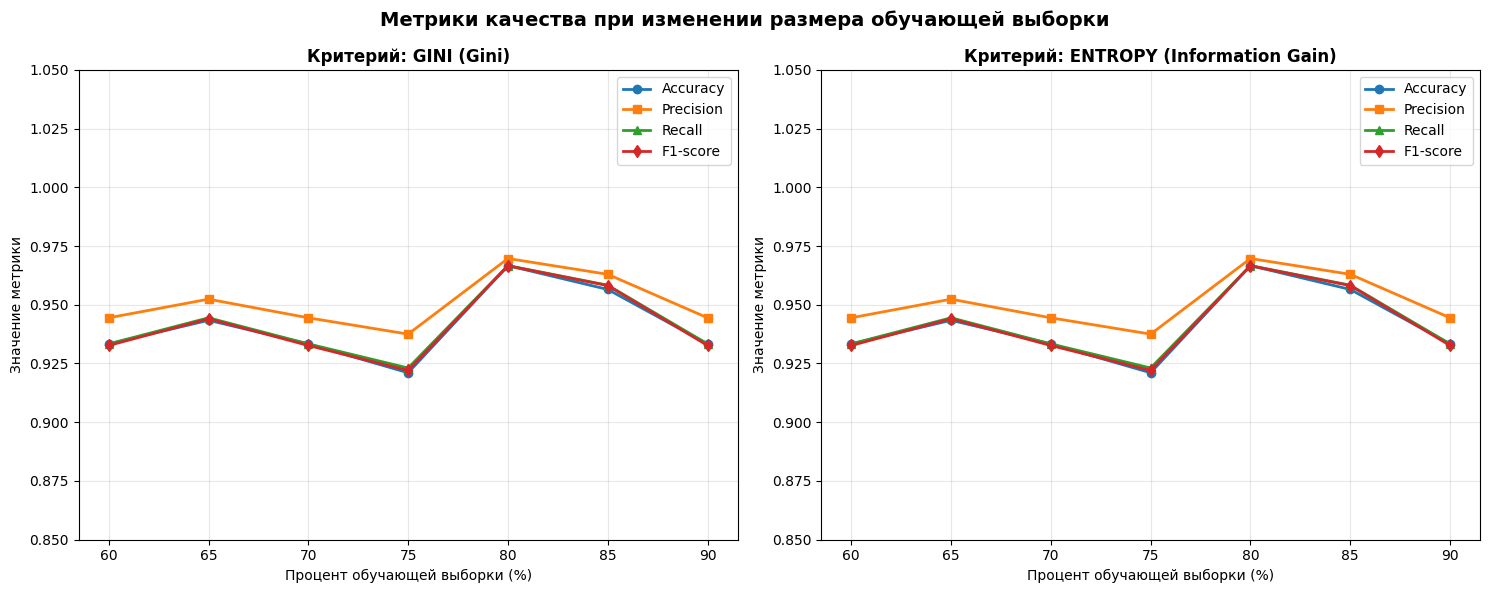

In [ ]:
# График всех метрик для обоих критериев
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, criterion in enumerate(criteria):
    ax = axes[idx]

    ax.plot(train_ratios, metrics[criterion]['accuracy'], marker='o', linewidth=2, label='Accuracy')
    ax.plot(train_ratios, metrics[criterion]['precision'], marker='s', linewidth=2, label='Precision')
    ax.plot(train_ratios, metrics[criterion]['recall'], marker='^', linewidth=2, label='Recall')
    ax.plot(train_ratios, metrics[criterion]['f1'], marker='d', linewidth=2, label='F1-score')

    ax.set_title(f'Критерий: {criterion.upper()} {"(Gini)" if criterion=="gini" else "(Information Gain)"}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Процент обучающей выборки (%)", fontsize=10)
    ax.set_ylabel("Значение метрики", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(train_ratios)
    ax.set_ylim(0.85, 1.05)

plt.suptitle("Метрики качества при изменении размера обучающей выборки",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()